# LR2 — Line-by-line explanation

## Task 1

1. Using EDA functions, answer about adult.data dataset:
   - a. How many rows and columns?
   - b. Any non-numeric columns?
   - c. Any missing values?
   - d. Average age?

In [29]:
# --- Import block ---

from typing import cast          # cast() — type hint helper; tells type checker "treat this as type X"
                                  # does nothing at runtime, purely for static analysis (mypy/pyright)
import numpy as np               # NumPy — library for numerical arrays and math operations
import pandas as pd              # Pandas — library for tabular data (DataFrames)

%matplotlib inline
# Jupyter magic: render matplotlib plots directly in notebook output

# --- Load dataset ---

df_income = cast(pd.DataFrame, pd.read_csv("adult.csv"))
# pd.read_csv("adult.csv")       — reads CSV file into DataFrame
# cast(pd.DataFrame, ...)        — tells type checker result is pd.DataFrame (read_csv can return
#                                   DataFrame | TextFileReader depending on args; cast removes ambiguity)

# --- Answer questions ---

print(f"a. datashape: {df_income.shape}")
# df_income.shape                — tuple (rows, columns), e.g. (48842, 15)

print(f"b. is non-numerical columns (yes): {df_income.dtypes[df_income.dtypes == 'str'].count()}")
# df_income.dtypes               — Series: column name → dtype (int64, float64, object, str...)
# [df_income.dtypes == 'str']    — boolean filter: keep only columns with dtype 'str'
# .count()                       — count how many such columns exist
# Result: 9 non-numerical (string/categorical) columns

null_counts = df_income.isnull().sum()
# df_income.isnull()             — DataFrame of same shape, True where value is NaN/None
# .sum()                         — sum True values per column → Series of null counts per column

print(f"c. null entries (none): {null_counts[null_counts != 0].count()}")
# null_counts[null_counts != 0]  — filter: keep only columns that have at least 1 null
# .count()                       — how many such columns. Result: 0 (no nulls in dataset)

print(f"d. average age: {float(np.average(df_income['age'].values))}")
# df_income['age']               — select 'age' column (Series)
# .values                        — extract raw NumPy array from Series
# np.average(...)                — compute arithmetic mean of array
# Result: ~38.64

a. datashape: (48842, 15)
b. is non-numerical columns (yes): 9
c. null entries (none): 0
d. average age: 38.64358543876172


## Task 2

Perform EDA on chosen dataset (adult.csv continues from Task 1)

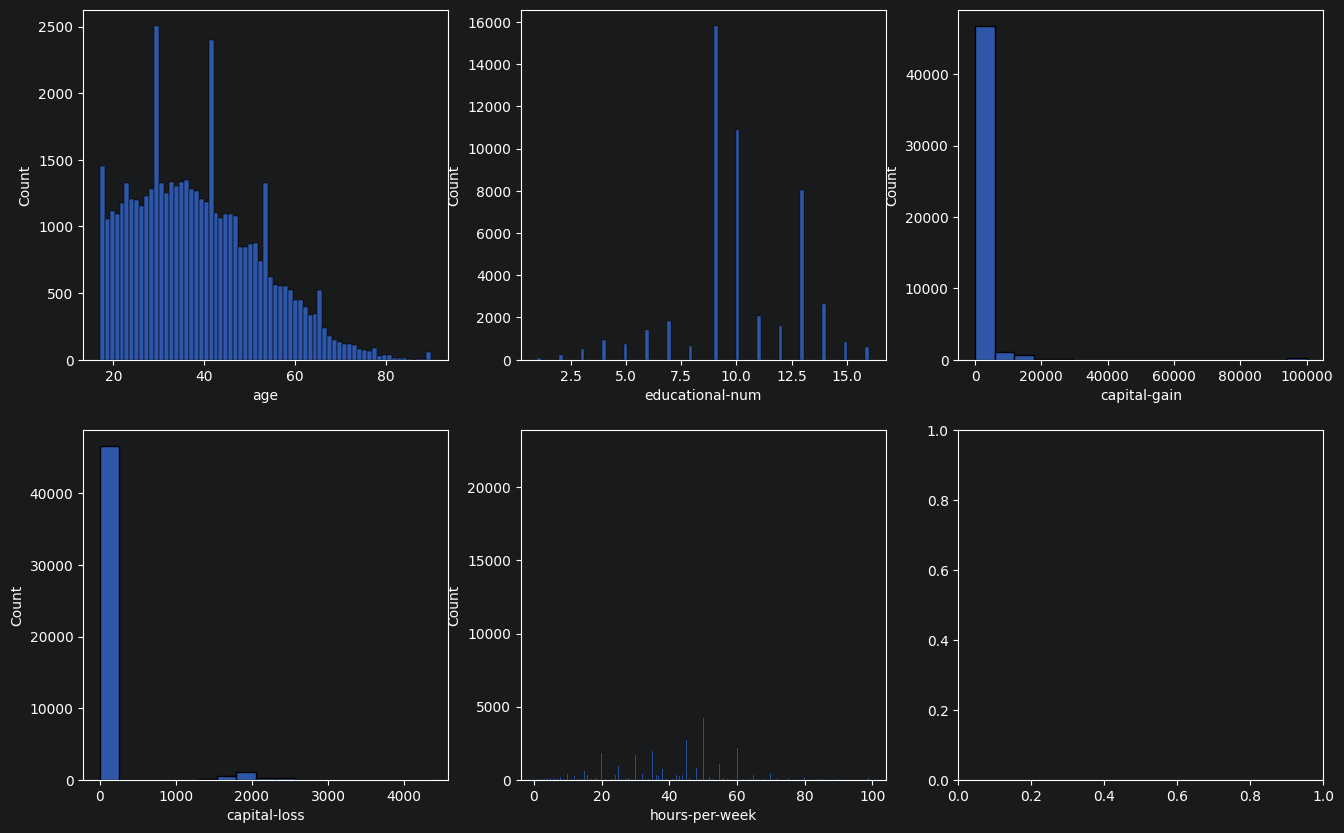

In [48]:
# --- Visualization imports ---

import matplotlib.pyplot as plt   # pyplot — MATLAB-style plotting API
import seaborn as sns             # seaborn — statistical visualization built on matplotlib
%matplotlib inline
# (repeated) ensure plots render inline

# ============================================================
# 1. Numeric feature distributions (histograms)
# ============================================================
# GOAL: understand shape of each numeric feature before modeling.
# We look for: skewness, outliers, multimodality, concentration around specific values.
# This informs whether features need transformation (log, normalization) for ML.

num_cols = df_income.select_dtypes(include=np.number).columns.tolist()
# select_dtypes(include=np.number) — keep only numeric columns (int64, float64)
# .columns                         — Index of column names
# .tolist()                        — convert to plain Python list
# Result: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
num_cols.remove('fnlwgt')

_, axes = plt.subplots(2, 3, figsize=(16, 10))
# plt.subplots(2, 3)  — create figure with 2×3 grid of subplots (6 total)
# figsize=(16, 10)    — figure dimensions in inches (width × height)
# fig                 — Figure object (whole canvas)
# axes                — 2D array of Axes objects (individual plots)

axes = axes.flatten()
# flatten 2D array (2×3) → 1D array (6) for easier iteration by index

for i, col in enumerate(num_cols):
    sns.histplot(data=df_income[col], ax=axes[i])

# ---- Conclusions ----
# - age: roughly normal distribution, slight right skew. Bulk of data in 25-45 range.
# - fnlwgt: heavy right skew — few extreme values. This is a census sampling weight,
#   not a meaningful personal attribute. May be irrelevant for income prediction.
# - educational-num: multimodal — peaks at 9 (HS-grad), 10 (some-college), 13 (Bachelors).
#   Education is ordinal/discrete, not continuous.
# - capital-gain / capital-loss: extreme skew — vast majority = 0, rare large outliers.
#   Most people have no investment income. Non-zero values likely strong signal for >50K.
# - hours-per-week: sharp peak at 40 (standard workweek), right tail = overworkers.
#
# Hypothesis to verify further:
#   1) capital-gain and education are likely strongest numeric predictors of income.
#   2) Skewed features (capital-gain/loss) may need log-transform or binning for modeling.
#   3) fnlwgt likely has no predictive value — correlation matrix (step 2) should confirm.

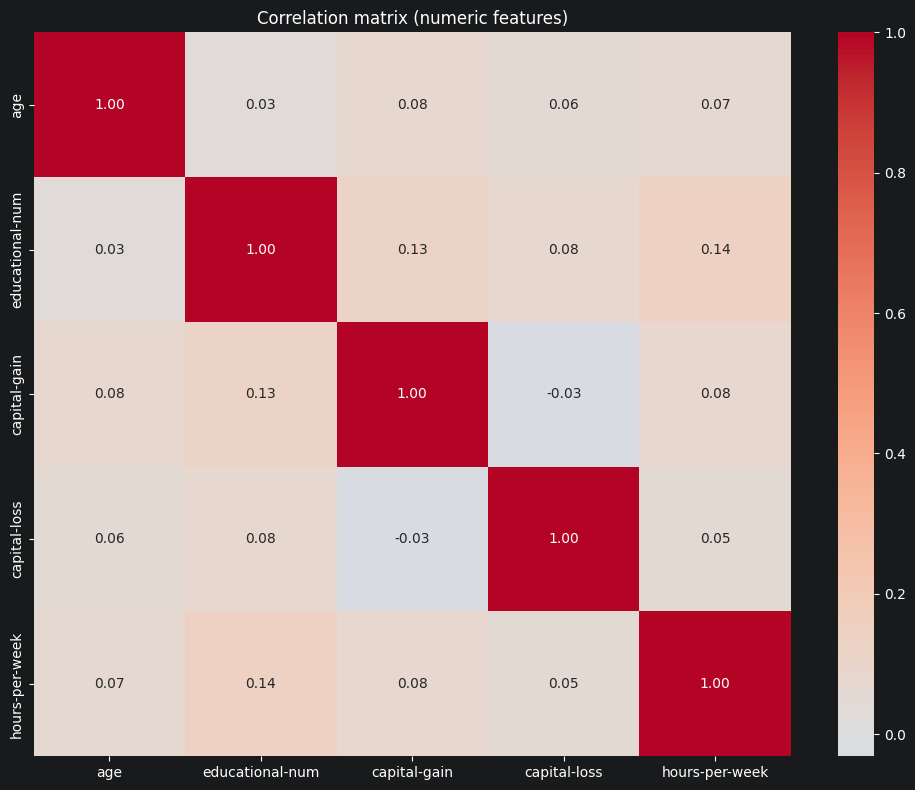

In [31]:
# ============================================================
# 2. Correlation matrix (heatmap)
# ============================================================
# GOAL: detect linear relationships between numeric features.
# We look for: strong correlations (|r| > 0.5) that indicate redundancy or predictive pairs,
# and near-zero correlations that confirm feature independence.

plt.figure(figsize=(10, 8))
# create new standalone figure 10×8 inches

corr = df_income[num_cols].corr()
# df_income[num_cols]  — subset DataFrame to numeric columns only
# .corr()              — compute Pearson correlation matrix (each pair of columns)
# Result: 6×6 DataFrame, values in [-1, 1]
# 1 = perfect positive correlation, -1 = perfect negative, 0 = no linear relationship

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
# sns.heatmap      — draw color-coded matrix
# annot=True       — print correlation values inside each cell
# fmt='.2f'        — format numbers to 2 decimal places
# cmap='coolwarm'  — blue (negative) → white (zero) → red (positive) colormap
# center=0         — align colormap center at 0 (white = no correlation)

plt.title('Correlation matrix (numeric features)')
plt.tight_layout()
plt.show()

# ---- Conclusions ----
# - Most features have weak correlations (near 0) — they carry independent information.
# - No strong multicollinearity detected — all features can stay in model without
#   redundancy issues (no need to drop correlated duplicates).
# - capital-gain and capital-loss are nearly uncorrelated with each other (~0) —
#   they represent different financial behaviors (investing vs losing).
#
# Note: Pearson correlation only captures LINEAR relationships.
# Non-linear dependencies (e.g., education → income) won't show here.
# Boxplots (step 3) and pairplot (step 7) help catch those.

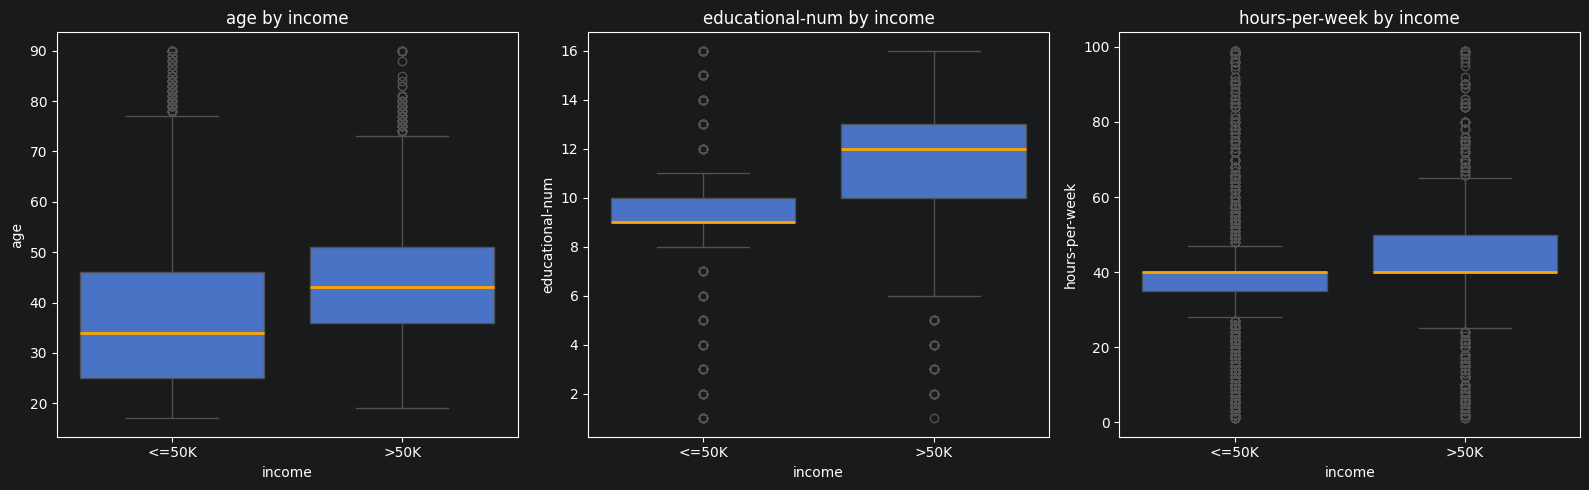

In [40]:
# ============================================================
# 3. Boxplots of numeric features grouped by income
# ============================================================
# GOAL: visually compare feature distributions between income groups (<=50K vs >50K).
# We look for: shifted medians, different spreads, or outlier patterns between groups.
# If a feature's boxplots look very different per group — it's a good predictor.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes = axes.flatten()

num_cols = [c for c in num_cols if c != ['capital-gain','capital-loss']]

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_income, x='income', y=col, ax=axes[i], medianprops={'color': 'orange', 'linewidth': 2})
    # sns.boxplot          — draw box-and-whisker plot
    # data=df_income       — source DataFrame
    # x='income'           — categorical axis (<=50K vs >50K)
    # y=col                — numeric axis (current feature)
    # ax=axes[i]           — draw on i-th subplot
    #
    # Box shows: median (line), Q1-Q3 (box), whiskers (1.5×IQR), outliers (dots)
    # Purpose: compare feature distributions between income groups
    axes[i].set_title(f'{col} by income')

plt.tight_layout()
plt.show()

# ---- Conclusions ----
# - age: >50K group has higher median (~44 vs ~33). Confirms: older = higher income.
# - educational-num: clear shift — >50K median higher (~13 vs ~9). Education matters.
#   This confirms hypothesis #1: education is a strong predictor.
# - capital-gain: >50K group has far more non-zero outliers. Most <=50K = 0.
#   Confirms hypothesis #1: capital-gain is strong signal for high income.
# - capital-loss: similar pattern but weaker than capital-gain.
# - hours-per-week: >50K group works slightly more (median ~45 vs ~40).
#
# Summary: age, educational-num, and capital-gain show clearest separation between
# income groups. These should be primary numeric features for classification model.

['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']


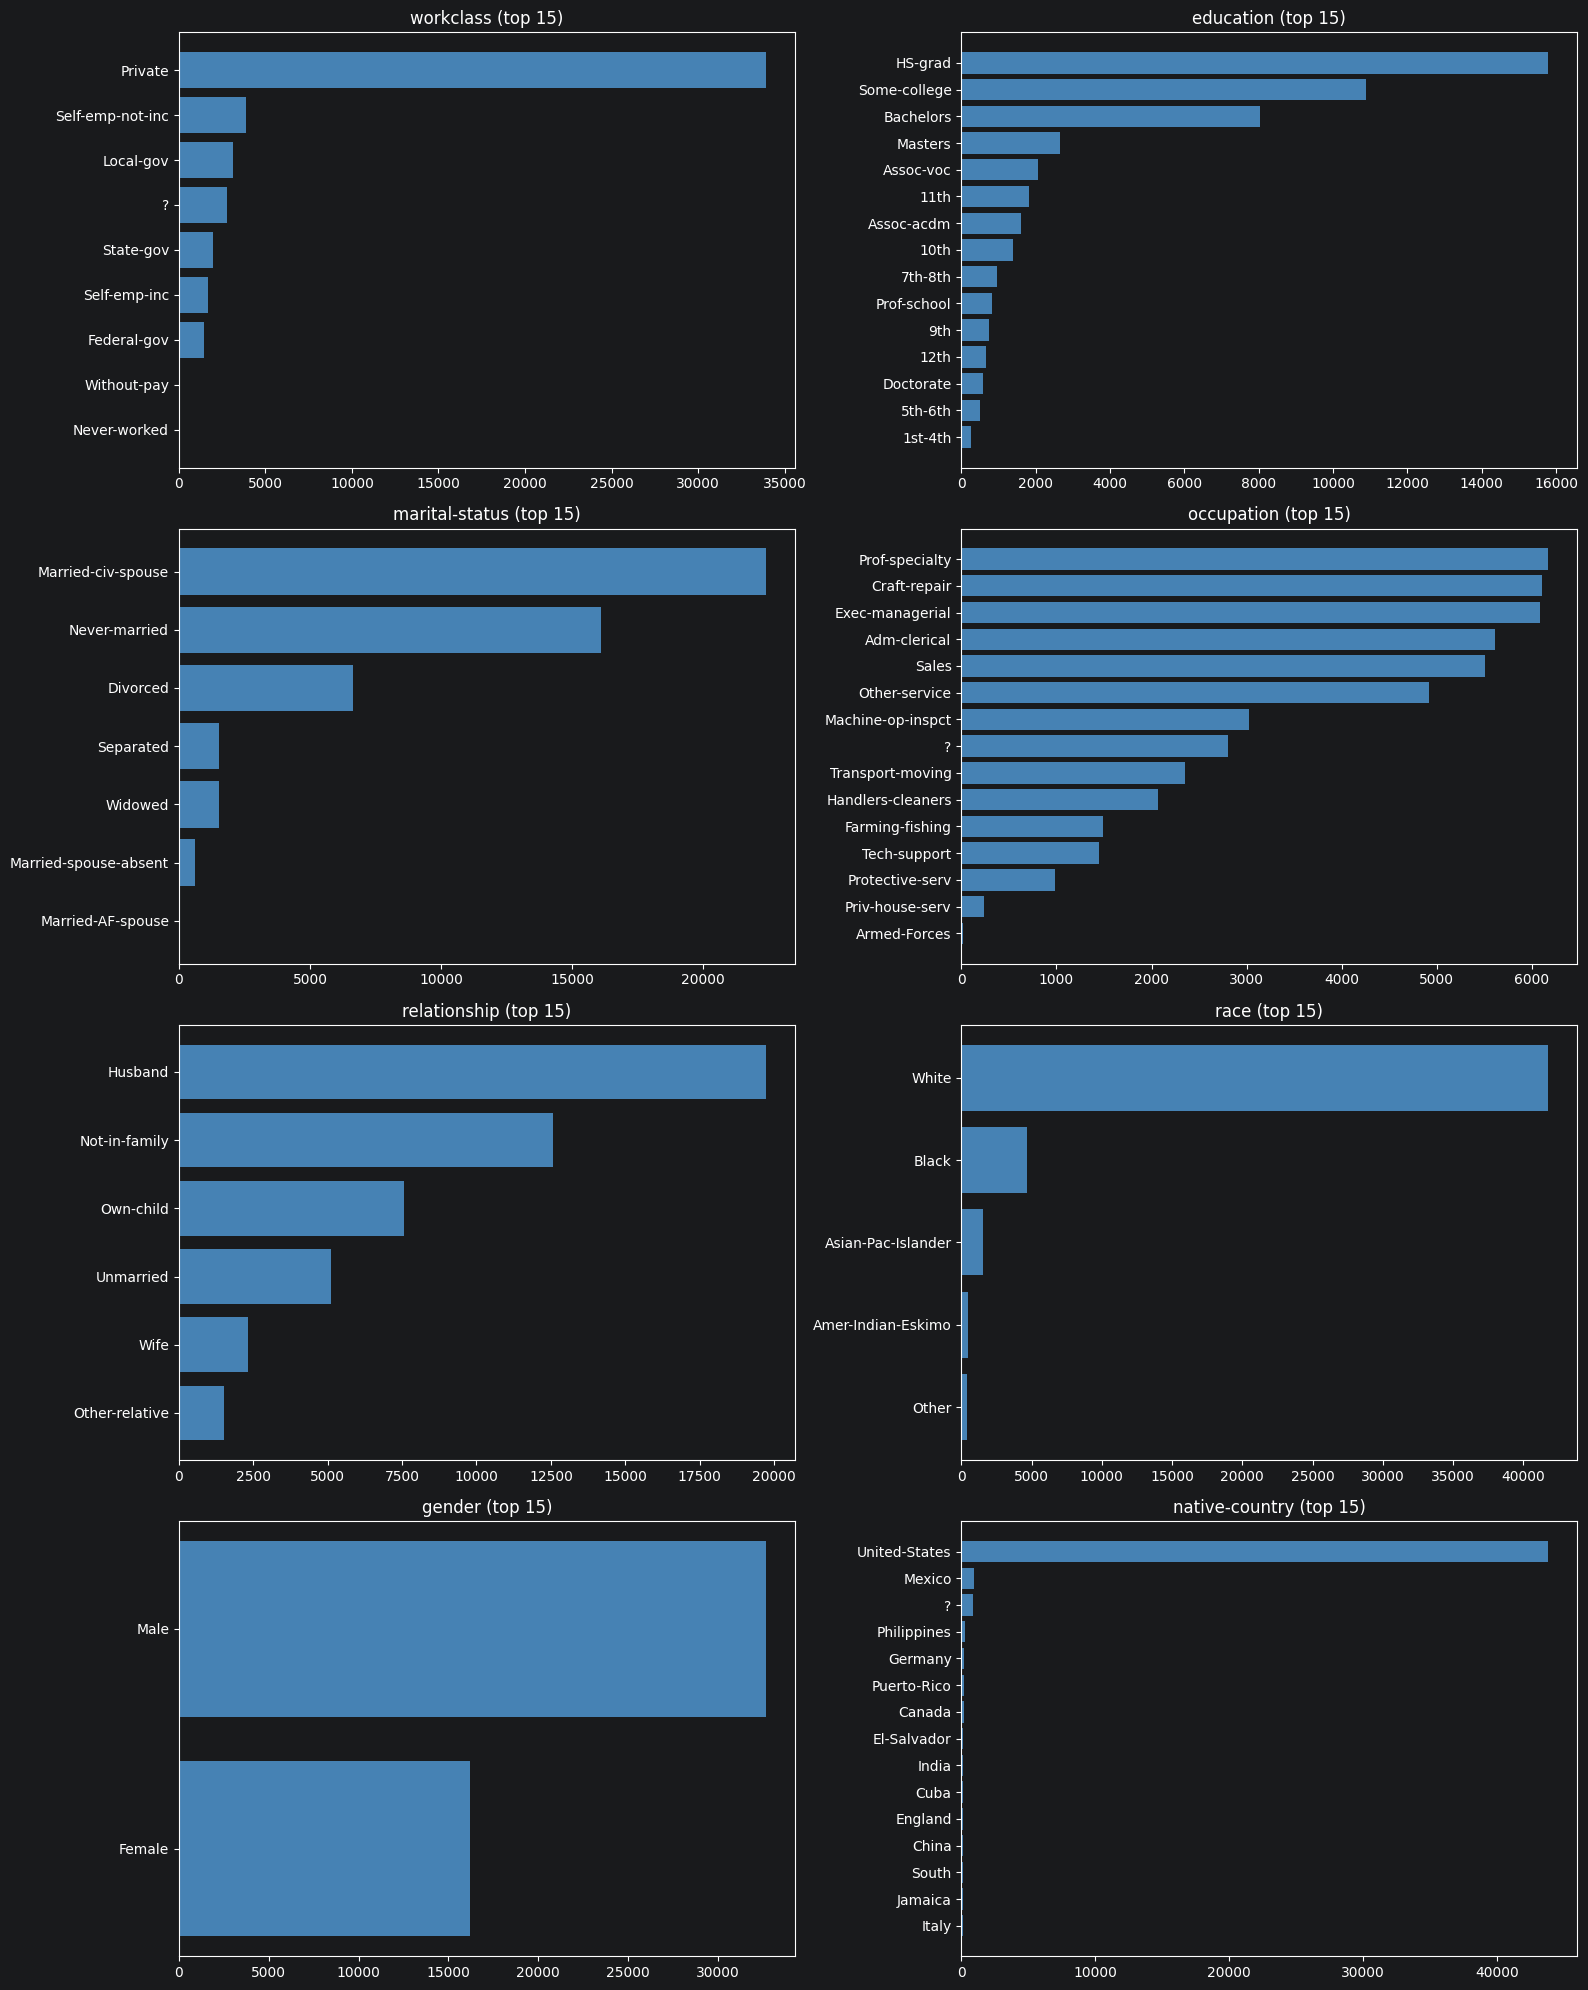

In [33]:
# ============================================================
# 4. Categorical features — horizontal bar charts (top 15 values)
# ============================================================
# GOAL: understand distribution of categorical features.
# We look for: dominant categories, rare categories, and features with high cardinality.
# This informs encoding strategy (one-hot vs ordinal vs target encoding).

cat_cols = df_income.select_dtypes(include=['object','str']).columns.tolist()
# select_dtypes(include=['object','str']) — keep columns with string/categorical dtype
# Result: list of 9 categorical column names

print(cat_cols)

cat_cols.remove('income')
# remove 'income' from list — it's target variable, will be plotted separately in step 5
# Now 8 categorical columns remain

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
# 4×2 grid = 8 subplots (one per remaining categorical column)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df_income[col].value_counts().head(15)
    # .value_counts()  — count occurrences of each unique value, sorted descending
    # .head(15)        — take top 15 most frequent values (avoid clutter)

    axes[i].barh(counts.index, counts.values, color='steelblue')
    # .barh()          — horizontal bar chart
    # counts.index     — category labels (Y axis)
    # counts.values    — frequencies (X axis / bar length)

    axes[i].set_title(f'{col} (top 15)')
    axes[i].invert_yaxis()
    # invert Y axis so most frequent category is at top


plt.tight_layout()
plt.show()

# ---- Conclusions ----
# - workclass: "Private" dominates (~75%). Government and self-employed are minorities.
#   Hypothesis: self-employed and government workers may have different income patterns.
# - education: "HS-grad" most common, then "Some-college", "Bachelors".
#   Matches educational-num histogram peaks.
# - marital-status: "Married-civ-spouse" largest group. Marital status correlates
#   with income — married people tend to be older with more career experience,
#   and higher earners are statistically more likely to be married (selection bias).
# - occupation: relatively balanced — no single occupation dominates heavily.
#   "Prof-specialty" and "Craft-repair" are top. Occupation likely strong predictor.
# - relationship: "Husband" most common — reflects dataset's demographic skew.
# - race: "White" dominates (~85%). Dataset is demographically imbalanced.
# - gender: more males than females — another demographic skew.
# - native-country: "United-States" overwhelmingly dominant (~90%).
#   Most other countries have very few entries — high cardinality, low signal.
#   Consider grouping rare countries into "Other" for modeling.
#
# Key takeaway: marital-status, occupation, and education are likely
# most informative categorical predictors. native-country needs grouping.

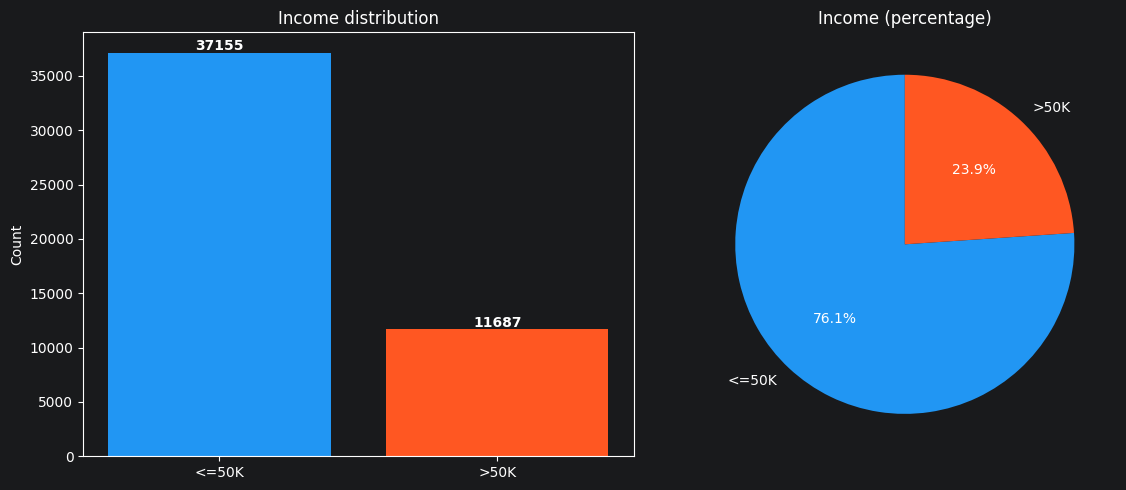


Class balance:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Ratio: 3.18 : 1


In [34]:
# ============================================================
# 5. Target variable — income distribution (bar + pie)
# ============================================================
# GOAL: assess class balance of target variable.
# We look for: ratio between classes. Heavy imbalance affects model training —
# a naive model can get high accuracy by always predicting majority class.

_, axes = plt.subplots(1, 2, figsize=(12, 5))
# 1×2 grid: bar chart left, pie chart right

income_counts = df_income['income'].value_counts()
# count <=50K and >50K occurrences

# --- Left: bar chart ---
axes[0].bar(income_counts.index, income_counts.values, color=['#2196F3', '#FF5722'])
# .bar()               — vertical bar chart
# color=[blue, orange]  — different color per income class

axes[0].set_title('Income distribution')
axes[0].set_ylabel('Count')

for j, v in enumerate(income_counts.values):
    axes[0].text(j, v + 200, str(v), ha='center', fontweight='bold')
    # .text(x, y, string)  — place text label above each bar
    # j                    — bar position (0 or 1)
    # v + 200              — slightly above bar top
    # ha='center'          — horizontal alignment

# --- Right: pie chart ---
axes[1].pie(income_counts.values, labels=income_counts.index, autopct='%1.1f%%',
            colors=['#2196F3', '#FF5722'], startangle=90)
# .pie()               — pie chart
# labels               — slice labels (<=50K, >50K)
# autopct='%1.1f%%'    — show percentage with 1 decimal inside each slice
# startangle=90        — rotate pie so first slice starts at 12 o'clock

axes[1].set_title('Income (percentage)')

plt.tight_layout()
plt.show()

print(f"\nClass balance:\n{income_counts}")
print(f"\nRatio: {income_counts.values[0]/income_counts.values[1]:.2f} : 1")
# Ratio shows class imbalance: how many times more <=50K than >50K

# ---- Conclusions ----
# - Dataset is imbalanced: ~76% earn <=50K, ~24% earn >50K (roughly 3:1 ratio).
# - This is moderate imbalance — not extreme, but enough to affect model evaluation.
# - Practical implications for modeling:
#   1) Accuracy alone is misleading — a model predicting always <=50K gets ~76% accuracy.
#   2) Should use stratified train/test split to preserve class ratio in both sets.
#   3) Evaluation metrics should include precision, recall, F1 — not just accuracy.
#   4) May consider class weights or oversampling (SMOTE) if model underperforms on >50K.

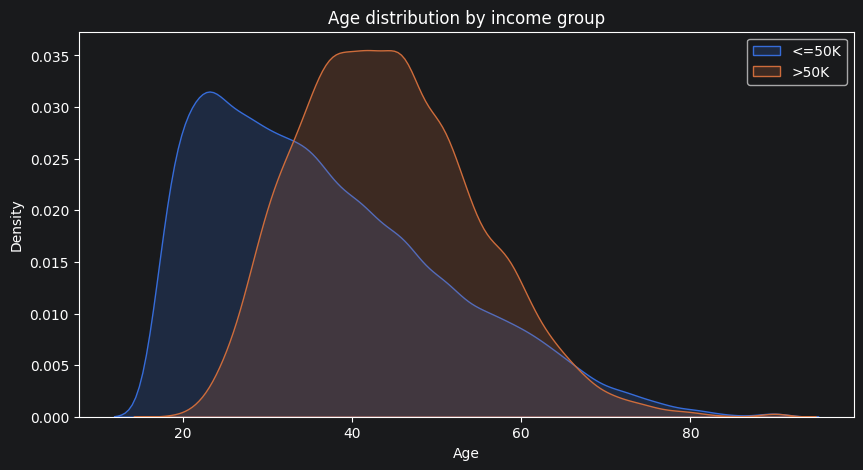

In [35]:
# ============================================================
# 6. Age distribution by income — KDE (Kernel Density Estimation)
# ============================================================
# GOAL: compare age distributions between income groups with smooth curves.
# We look for: shifted peaks, different spreads, overlap area.
# Less overlap = better separability by this feature alone.

plt.figure(figsize=(10, 5))

for label in df_income['income'].unique():
    # .unique()  — array of distinct values: ['<=50K', '>50K']
    # loop draws one KDE curve per income group

    subset = df_income[df_income['income'] == label]
    # boolean indexing: filter rows where income matches current label

    sns.kdeplot(subset['age'], label=label, fill=True, alpha=0.2)
    # sns.kdeplot      — smooth density estimate (like smoothed histogram)
    # KDE uses Gaussian kernels centered at each data point, sums them
    # fill=True        — fill area under curve
    # alpha=0.2        — transparency (20% opaque) so curves overlap visibly
    # label            — legend entry

plt.title('Age distribution by income group')
plt.xlabel('Age')
plt.legend()   # show legend with labels from each kdeplot call
plt.show()

# ---- Conclusions ----
# - <=50K peaks earlier (~25-30), >50K peaks later (~35-50).
# - There is significant overlap in 30-50 range — age alone cannot separate classes.
# - Young people (<25) are almost exclusively <=50K — makes sense (early career).
# - After 60, both groups decline — retirement age.
#
# Confirms boxplot finding: age is useful but insufficient as sole predictor.
# Combined with education and capital-gain, age adds meaningful signal.

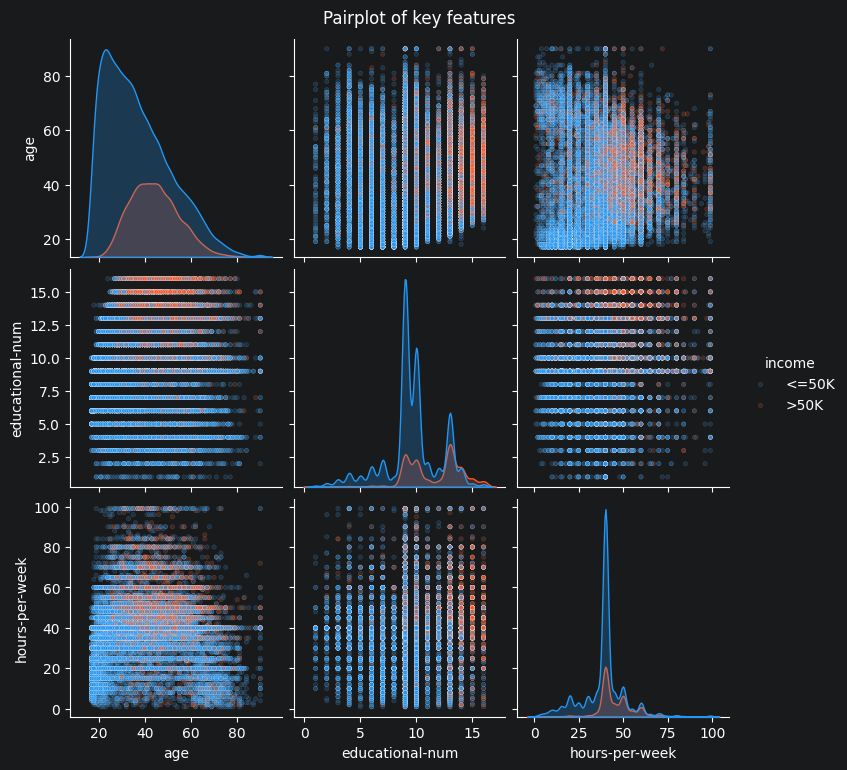

In [49]:
# ============================================================
# 7. Pairplot of key numeric features
# ============================================================
# GOAL: visualize pairwise relationships and class separability across multiple features.
# We look for: clusters of same-color points, visible boundaries between classes,
# feature combinations that separate income groups better than individual features.

sns.pairplot(df_income[['age', 'educational-num', 'hours-per-week', 'income']],
             hue='income', diag_kind='kde', palette={'<=50K': '#2196F3', '>50K': '#FF5722'},
             plot_kws={'alpha': 0.2, 's': 10})
# sns.pairplot — NxN grid of scatter plots for all feature pairs
#
# Arguments:
# df_income[['age', ...]]  — subset of 4 numeric features + 'income' for coloring
# hue='income'             — color points by income class
# diag_kind='kde'          — diagonal cells show KDE instead of histogram
#                            (each feature's distribution, split by income)
# palette={...}            — explicit color mapping per class
# plot_kws={'alpha': 0.2, 's': 10}
#   alpha=0.2              — transparent dots (dataset is large, prevents overplotting)
#   s=10                   — small dot size
#
# Grid layout:
# - Diagonal: KDE of each feature split by income
# - Off-diagonal: scatter plot of feature_i vs feature_j, colored by income
# - Grid is symmetric (upper-left = mirror of lower-right)
#
# Purpose: spot clusters, separability, and relationships between key features

plt.suptitle('Pairplot of key features', y=1.02)
# suptitle — "super title" above entire figure
# y=1.02   — push title slightly above figure boundary to avoid overlap

plt.show()

# ---- Conclusions ----
# - capital-gain stands out: visible horizontal "stripe" of orange (>50K) points
#   at high capital-gain values across all feature pairs. Strongest visual separator.
# - age vs educational-num: >50K points concentrate in upper-right quadrant
#   (older + more educated). Confirms both features contribute jointly.
# - hours-per-week vs age: >50K cluster around 40-60 hours, age 30-55.
#   Working more hours alone doesn't guarantee high income — needs context.
# - Diagonal KDEs confirm earlier findings: shifted peaks for age and education,
#   extreme spike at 0 for capital-gain.
#
# Overall EDA summary:
# Top numeric predictors: capital-gain > educational-num > age > hours-per-week
# Top categorical predictors (from step 4): marital-status, occupation, education
# fnlwgt: confirmed irrelevant — consider dropping.
# Class imbalance: 3:1 — use stratified splits and F1 metric for evaluation.
# Feature engineering ideas: log-transform capital-gain/loss, group rare countries.